In [ ]:
!pip install mne scikit-learn seaborn --quiet

import os
import numpy as np
import pandas as pd
import mne
import pickle
from scipy.signal import hilbert
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
print("Imports done!")

Imports done!


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ROOT_PATH = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data"
DATA_PATH = "/content/drive/MyDrive/Alzheimers Research/OpenNeuro_Data/derivatives"
participants = pd.read_csv(os.path.join(ROOT_PATH, "participants.tsv"), sep="\t")
GROUP_COL = "Group"
print("Drive mounted!")
print(participants.head())

Mounted at /content/drive
Drive mounted!
  participant_id Gender  Age Group  MMSE
0        sub-001      F   57     A    16
1        sub-002      F   78     A    22
2        sub-003      M   70     A    14
3        sub-004      F   67     A    20
4        sub-005      M   70     A    22


In [ ]:
BANDS = {
    "Delta": (0.5, 4),
    "Theta": (4, 8),
    "Alpha": (8, 13),
    "Beta":  (13, 25),
    "Gamma": (25, 45),
    # Mu removed
}

ELECTRODES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
              'T3','C3','Cz','C4','T4',
              'T5','P3','Pz','P4','T6','O1','O2']

def band_power(raw, fmin, fmax):
    return np.mean(raw.compute_psd(fmin=fmin, fmax=fmax).get_data())

def kuramoto(raw, fmin, fmax):
    data = raw.get_data()
    data = mne.filter.filter_data(data, raw.info['sfreq'], fmin, fmax, verbose=False)
    phases = np.angle(hilbert(data))
    return np.mean(np.abs(np.mean(np.exp(1j * phases), axis=0)))

def electrode_band_power(raw, fmin, fmax):
    psd = raw.compute_psd(fmin=fmin, fmax=fmax)
    return psd.get_data().mean(axis=-1)

print("Functions defined!")

Functions defined!


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/Alzheimers Research/results_cache_v2.pkl"

if os.path.exists(SAVE_PATH):
    with open(SAVE_PATH, "rb") as f:
        results = pickle.load(f)
    already_done = {r["subject"] for r in results}
    if results and "elec_Fp1_Delta" not in results[0]:
        print("Old cache — reprocessing...")
        results = []
        already_done = set()
    else:
        print(f"Loaded {len(results)} cached subjects")
else:
    results = []
    already_done = set()

for subj in sorted(os.listdir(DATA_PATH)):
    if not subj.startswith("sub-"):
        continue
    if subj in already_done:
        print(f"Skipping {subj} (cached)")
        continue
    eeg_path = os.path.join(DATA_PATH, subj, "eeg")
    if not os.path.exists(eeg_path):
        continue
    for f in os.listdir(eeg_path):
        if not f.endswith(".set"):
            continue
        try:
            raw = mne.io.read_raw_eeglab(
                os.path.join(eeg_path, f), preload=True, verbose=False)
            row   = participants[participants['participant_id'] == subj]
            group = row[GROUP_COL].values[0] if len(row) else "unknown"
            entry = {"subject": subj, "group": group}
            for band, (fmin, fmax) in BANDS.items():
                entry[f"power_{band}"]    = band_power(raw, fmin, fmax)
                entry[f"kuramoto_{band}"] = kuramoto(raw, fmin, fmax)
                elec_powers = electrode_band_power(raw, fmin, fmax)
                ch_names = [ch.upper() for ch in raw.ch_names]
                for elec in ELECTRODES:
                    if elec in ch_names:
                        idx = ch_names.index(elec)
                        entry[f"elec_{elec}_{band}"] = elec_powers[idx]
                    else:
                        entry[f"elec_{elec}_{band}"] = 0.0  # 0 not NaN!
            results.append(entry)
            print(f"Processed {subj} ({len(results)}/88)")
            with open(SAVE_PATH, "wb") as f_save:
                pickle.dump(results, f_save)
        except Exception as e:
            print(f"Error {subj}: {e}")

# NO dropna — just fillna(0)
df = pd.DataFrame(results).fillna(0)
print(f"\nDone! {len(df)} subjects")
print(df['group'].value_counts())

Loaded 88 cached subjects
Skipping sub-001 (cached)
Skipping sub-002 (cached)
Skipping sub-003 (cached)
Skipping sub-004 (cached)
Skipping sub-005 (cached)
Skipping sub-006 (cached)
Skipping sub-007 (cached)
Skipping sub-008 (cached)
Skipping sub-009 (cached)
Skipping sub-010 (cached)
Skipping sub-011 (cached)
Skipping sub-012 (cached)
Skipping sub-013 (cached)
Skipping sub-014 (cached)
Skipping sub-015 (cached)
Skipping sub-016 (cached)
Skipping sub-017 (cached)
Skipping sub-018 (cached)
Skipping sub-019 (cached)
Skipping sub-020 (cached)
Skipping sub-021 (cached)
Skipping sub-022 (cached)
Skipping sub-023 (cached)
Skipping sub-024 (cached)
Skipping sub-025 (cached)
Skipping sub-026 (cached)
Skipping sub-027 (cached)
Skipping sub-028 (cached)
Skipping sub-029 (cached)
Skipping sub-030 (cached)
Skipping sub-031 (cached)
Skipping sub-032 (cached)
Skipping sub-033 (cached)
Skipping sub-034 (cached)
Skipping sub-035 (cached)
Skipping sub-036 (cached)
Skipping sub-037 (cached)
Skipping sub

In [ ]:
power_cols    = [f"power_{b}"    for b in BANDS]
kuramoto_cols = [f"kuramoto_{b}" for b in BANDS]
elec_cols     = [f"elec_{e}_{b}" for b in BANDS for e in ELECTRODES]
feature_cols  = power_cols + kuramoto_cols + elec_cols  # ALL features

X = df[feature_cols].values
y = df["group"].values

le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.90, random_state=42)
X_reduced = pca.fit_transform(X_scaled)

print(f"Subjects:            {len(df)}")
print(f"Original features:   {X_scaled.shape[1]}")
print(f"After PCA:           {X_reduced.shape[1]} components")
print(f"Variance explained:  {pca.explained_variance_ratio_.sum():.1%}")

Subjects:            88
Original features:   105
After PCA:           6 components
Variance explained:  90.6%


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Tuning SVM...")
param_grid = {
    "C":      [0.1, 1, 10, 100],
    "gamma":  ["scale", "auto", 0.001, 0.01],
    "kernel": ["rbf", "linear"]
}
grid = GridSearchCV(
    SVC(probability=True, class_weight="balanced", random_state=42),
    param_grid, cv=cv, scoring="balanced_accuracy", n_jobs=-1, verbose=0
)
grid.fit(X_reduced, y_encoded)
best_svm = grid.best_estimator_
print(f"Best SVM params: {grid.best_params_}")

models = {
    "SVM (tuned)":    best_svm,
    "Random Forest":  RandomForestClassifier(n_estimators=200,
                          class_weight="balanced", random_state=42),
    "Logistic Reg":   LogisticRegression(max_iter=1000,
                          class_weight="balanced", random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(32, 16),
                          max_iter=500, random_state=42),
}

results_cv = {}
print("\n=== Model Comparison (Balanced Accuracy) ===")
for name, model in models.items():
    scores = cross_val_score(model, X_reduced, y_encoded,
                             cv=cv, scoring="balanced_accuracy")
    results_cv[name] = scores
    print(f"{name:20s}: {scores.mean():.3f} ± {scores.std():.3f}")

for model in models.values():
    model.fit(X_reduced, y_encoded)

best_name  = max(results_cv, key=lambda k: results_cv[k].mean())
best_model = models[best_name]
print(f"\nBest model: {best_name} ({results_cv[best_name].mean():.3f})")

Tuning SVM...
Best SVM params: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}

=== Model Comparison (Balanced Accuracy) ===
SVM (tuned)         : 0.524 ± 0.089
Random Forest       : 0.457 ± 0.099
Logistic Reg        : 0.480 ± 0.137
Neural Network      : 0.491 ± 0.111

Best model: SVM (tuned) (0.524)


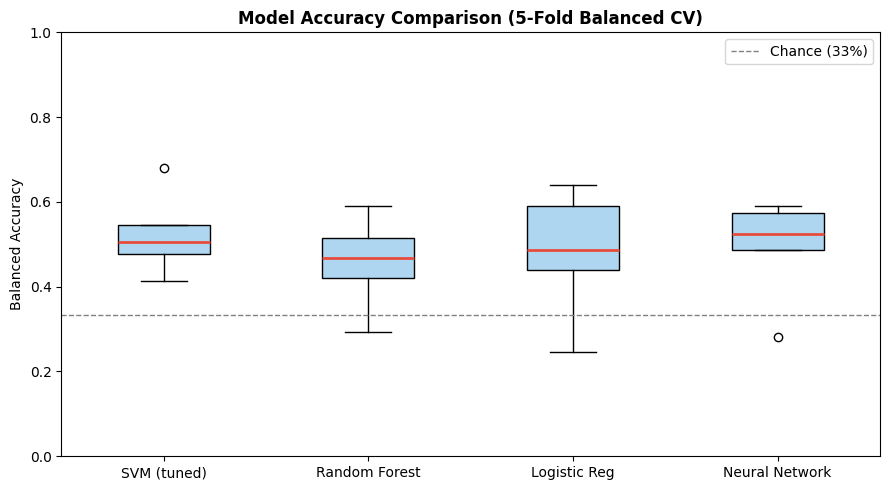

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(results_cv.values(), labels=results_cv.keys(),
           patch_artist=True,
           boxprops=dict(facecolor="#AED6F1"),
           medianprops=dict(color="#E74C3C", linewidth=2))
ax.axhline(1/3, color="gray", linestyle="--", linewidth=1, label="Chance (33%)")
ax.set_title("Model Accuracy Comparison (5-Fold Balanced CV)", fontweight="bold")
ax.set_ylabel("Balanced Accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

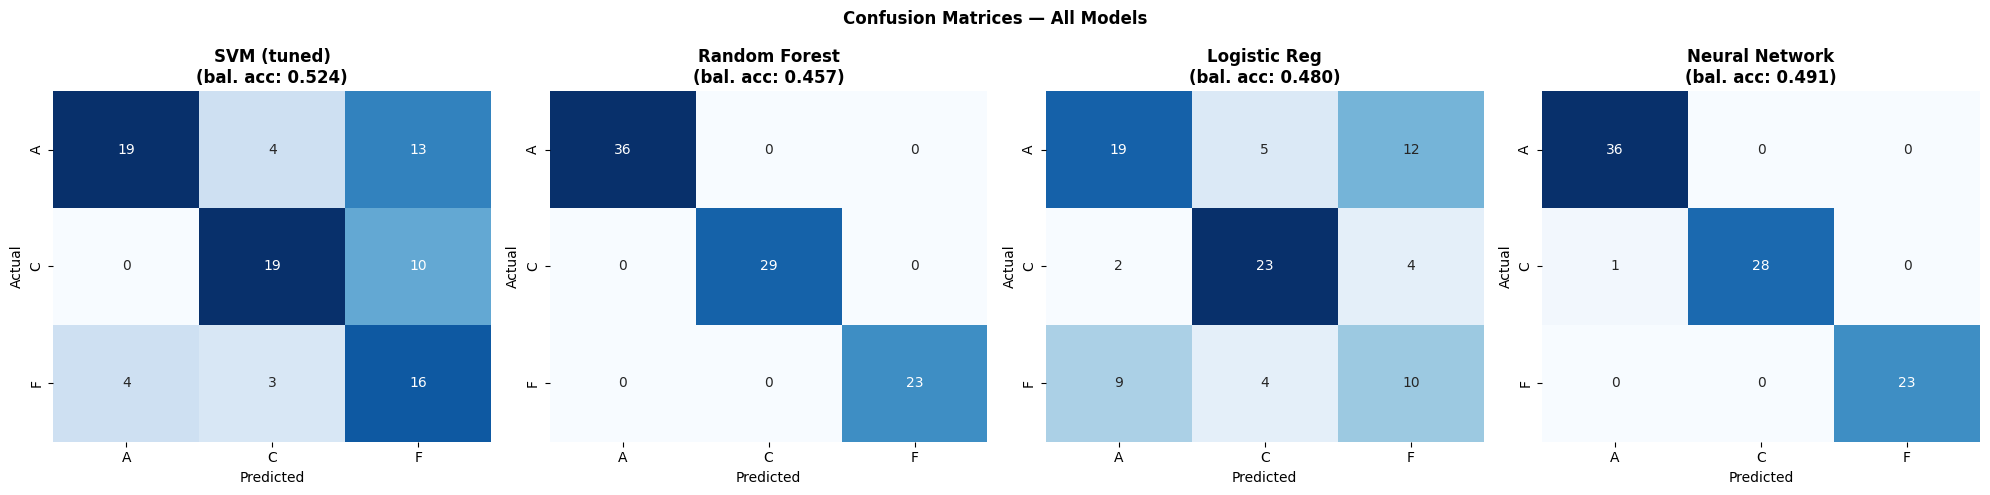

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Confusion Matrices — All Models", fontweight="bold")

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_reduced)
    cm = confusion_matrix(y_encoded, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap="Blues", cbar=False)
    acc = results_cv[name].mean()
    ax.set_title(f"{name}\n(bal. acc: {acc:.3f})", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("confusion_matrices_all.png", dpi=150, bbox_inches="tight")
plt.show()

Top 5 electrodes:
  1. O2: 0.017672
  2. P3: 0.016771
  3. F7: 0.015323
  4. T3: 0.015073
  5. O1: 0.013597


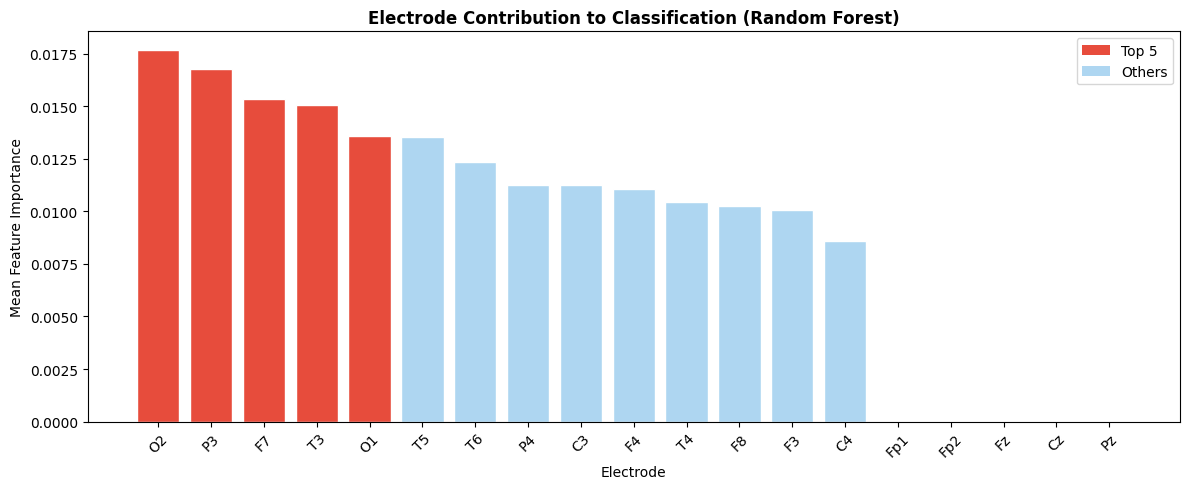

In [ ]:
# Train RF on full features (not PCA reduced) to get electrode importance
rf_full = RandomForestClassifier(n_estimators=200,
              class_weight="balanced", random_state=42)
rf_full.fit(X_scaled, y_encoded)  # X_scaled has all 126 features
importances = rf_full.feature_importances_

elec_importance = {elec: 0.0 for elec in ELECTRODES}
elec_count      = {elec: 0   for elec in ELECTRODES}

for i, feat in enumerate(feature_cols):
    for elec in ELECTRODES:
        if feat.startswith(f"elec_{elec}_"):
            elec_importance[elec] += importances[i]
            elec_count[elec]      += 1

for elec in ELECTRODES:
    if elec_count[elec] > 0:
        elec_importance[elec] /= elec_count[elec]

sorted_elecs = sorted(elec_importance, key=elec_importance.get, reverse=True)
sorted_vals  = [elec_importance[e] for e in sorted_elecs]

print("Top 5 electrodes:")
for i, e in enumerate(sorted_elecs[:5]):
    print(f"  {i+1}. {e}: {elec_importance[e]:.6f}")

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
colors = ["#E74C3C" if i < 5 else "#AED6F1" for i in range(len(sorted_elecs))]
ax.bar(sorted_elecs, sorted_vals, color=colors, edgecolor="white")
ax.set_title("Electrode Contribution to Classification (Random Forest)",
             fontweight="bold")
ax.set_ylabel("Mean Feature Importance")
ax.set_xlabel("Electrode")
ax.tick_params(axis='x', rotation=45)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#E74C3C", label="Top 5"),
                   Patch(facecolor="#AED6F1", label="Others")])
plt.tight_layout()
plt.savefig("electrode_importance_bar.png", dpi=150, bbox_inches="tight")
plt.show()

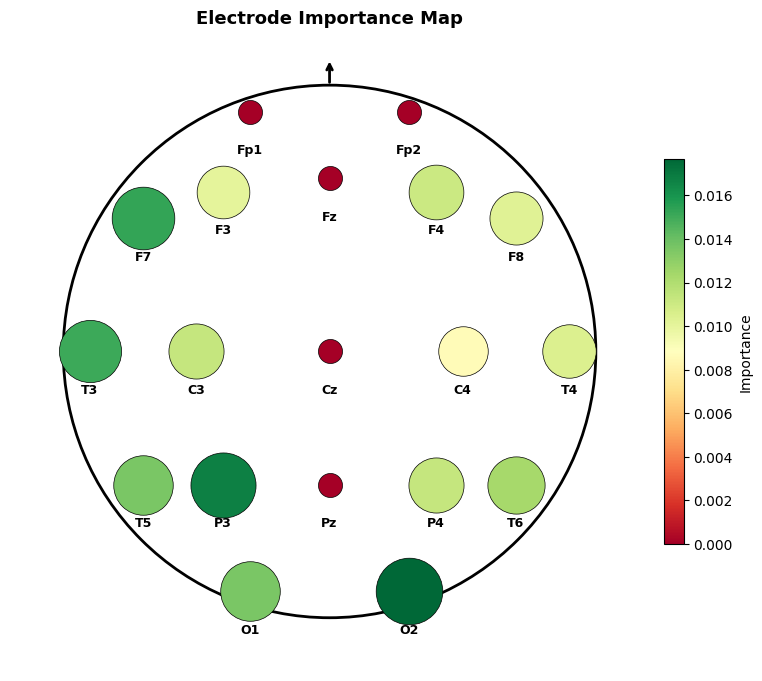

In [ ]:
elec_pos = {
    'Fp1': (-0.3, 0.9),  'Fp2': (0.3, 0.9),
    'F7':  (-0.7, 0.5),  'F3':  (-0.4, 0.6),  'Fz': (0.0, 0.65),
    'F4':  (0.4, 0.6),   'F8':  (0.7, 0.5),
    'T3':  (-0.9, 0.0),  'C3':  (-0.5, 0.0),  'Cz': (0.0, 0.0),
    'C4':  (0.5, 0.0),   'T4':  (0.9, 0.0),
    'T5':  (-0.7, -0.5), 'P3':  (-0.4, -0.5), 'Pz': (0.0, -0.5),
    'P4':  (0.4, -0.5),  'T6':  (0.7, -0.5),
    'O1':  (-0.3, -0.9), 'O2':  (0.3, -0.9),
}

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-1.2, 1.2)
ax.set_ylim(-1.2, 1.2)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title("Electrode Importance Map", fontweight="bold", fontsize=13)
head = plt.Circle((0, 0), 1.0, fill=False, color='black', linewidth=2)
ax.add_patch(head)
ax.annotate('', xy=(0, 1.1), xytext=(0, 1.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2))

max_imp = max(elec_importance.values())
min_imp = min(elec_importance.values())

for elec, (x, y) in elec_pos.items():
    imp  = elec_importance.get(elec, 0)
    norm = (imp - min_imp) / (max_imp - min_imp + 1e-10)
    size = 300 + norm * 2000
    ax.scatter(x, y, s=size, c=[plt.cm.RdYlGn(norm)],
               zorder=3, edgecolors='black', linewidth=0.5)
    ax.text(x, y - 0.12, elec, ha='center', va='top',
            fontsize=9, fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='RdYlGn',
     norm=plt.Normalize(vmin=min_imp, vmax=max_imp))
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02).set_label("Importance")
plt.tight_layout()
plt.savefig("electrode_importance_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ============================
# CELL 11 — Predict by pasting all values at once
# ============================
def predict_from_text(text):
    """Paste all values at once as a block of text"""
    entry = {}
    for line in text.strip().split("\n"):
        line = line.strip()
        if not line:
            continue
        key, val = line.split(":")
        key = key.strip()
        val = val.strip().split()[0]  # handles trailing comments
        entry[key] = float(val)

    # Fill electrode features with group means
    for b in BANDS:
        for e in ELECTRODES:
            entry[f"elec_{e}_{b}"] = df[f"elec_{e}_{b}"].mean()

    X_new         = np.array([[entry[f] for f in feature_cols]])
    X_new_scaled  = scaler.transform(X_new)
    X_new_reduced = pca.transform(X_new_scaled)
    pred  = le.inverse_transform(best_model.predict(X_new_reduced))[0]
    proba = best_model.predict_proba(X_new_reduced)[0]
    label = {"A": "Alzheimer's", "C": "Healthy Control", "F": "FTD"}[pred]

    print(f"\n=== Prediction ({best_name}) ===")
    print(f"Predicted: {label}")
    print(f"  A (Alzheimer's):  {proba[le.transform(['A'])[0]]:.1%}")
    print(f"  C (Healthy):      {proba[le.transform(['C'])[0]]:.1%}")
    print(f"  F (FTD):          {proba[le.transform(['F'])[0]]:.1%}")

# ---- Paste your values here ----
values = """
power_Delta:     3.54e-10
kuramoto_Delta:  0.932
power_Theta:     2.87e-11
kuramoto_Theta:  0.868
power_Alpha:     9.97e-12
kuramoto_Alpha:  0.720
power_Beta:      2.75e-12
kuramoto_Beta:   0.713
power_Gamma:     1.72e-12
kuramoto_Gamma:  0.775
power_Mu:        1.12e-11
kuramoto_Mu:     0.720
"""

predict_from_text(values)


=== Prediction (SVM (tuned)) ===
Predicted: Alzheimer's
  A (Alzheimer's):  45.1%
  C (Healthy):      28.7%
  F (FTD):          26.2%


In [ ]:
from scipy.signal import hilbert

def kuramoto_coupling_matrix(raw, fmin, fmax):
    data   = raw.get_data()
    data   = mne.filter.filter_data(data, raw.info['sfreq'],
                                     fmin, fmax, verbose=False)
    phases = np.angle(hilbert(data))
    n_ch   = phases.shape[0]
    K      = np.zeros((n_ch, n_ch))
    for i in range(n_ch):
        for j in range(n_ch):
            K[i, j] = np.abs(np.mean(np.exp(1j * (phases[i] - phases[j]))))
    return K

# Store per group per band
coupling_results = {g: {b: [] for b in BANDS} for g in ["A", "C", "F"]}
ch_names_global  = None

for subj in sorted(os.listdir(DATA_PATH)):
    if not subj.startswith("sub-"):
        continue
    eeg_path = os.path.join(DATA_PATH, subj, "eeg")
    if not os.path.exists(eeg_path):
        continue
    for f in os.listdir(eeg_path):
        if not f.endswith(".set"):
            continue
        try:
            raw   = mne.io.read_raw_eeglab(
                os.path.join(eeg_path, f), preload=True, verbose=False)
            row   = participants[participants['participant_id'] == subj]
            group = row[GROUP_COL].values[0] if len(row) else "unknown"
            if group not in ["A", "C", "F"]:
                continue
            if ch_names_global is None:
                ch_names_global = [ch.upper() for ch in raw.ch_names]
            for band, (fmin, fmax) in BANDS.items():
                K = kuramoto_coupling_matrix(raw, fmin, fmax)
                coupling_results[group][band].append(K)
            print(f"Processed {subj} ({group})")
        except Exception as e:
            print(f"Error {subj}: {e}")

# Average per group per band
mean_coupling = {
    g: {b: np.mean(coupling_results[g][b], axis=0)
        for b in BANDS if len(coupling_results[g][b]) > 0}
    for g in ["A", "C", "F"]
}
print(f"\nDone! Channel names: {ch_names_global}")

Processed sub-001 (A)
Processed sub-002 (A)
Processed sub-003 (A)
Processed sub-004 (A)
Processed sub-005 (A)
Processed sub-006 (A)
Processed sub-007 (A)
Processed sub-008 (A)
Processed sub-009 (A)
Processed sub-010 (A)
Processed sub-011 (A)
Processed sub-012 (A)
Processed sub-013 (A)
Processed sub-014 (A)
Processed sub-015 (A)
Processed sub-016 (A)
Processed sub-017 (A)
Processed sub-018 (A)
Processed sub-019 (A)
Processed sub-020 (A)
Processed sub-021 (A)
Processed sub-022 (A)
Processed sub-023 (A)
Processed sub-024 (A)
Processed sub-025 (A)
Processed sub-026 (A)
Processed sub-027 (A)
Processed sub-028 (A)
Processed sub-029 (A)
Processed sub-030 (A)
Processed sub-031 (A)
Processed sub-032 (A)
Processed sub-033 (A)
Processed sub-034 (A)
Processed sub-035 (A)
Processed sub-036 (A)
Processed sub-037 (C)
Processed sub-038 (C)
Processed sub-039 (C)
Processed sub-040 (C)
Processed sub-041 (C)
Processed sub-042 (C)
Processed sub-043 (C)
Processed sub-044 (C)
Processed sub-045 (C)
Processed 

In [ ]:
# ============================
# RUN THIS BEFORE THE COUPLING PLOTS
# ============================
import matplotlib.pyplot as plt
import numpy as np
import mne
from scipy.signal import hilbert
import os

GROUP_LABELS = {"A": "Alzheimer's (AD)", "C": "Healthy Control (CN)", "F": "FTD"}
GROUP_COLORS = {"A": "#E74C3C",          "C": "#2ECC71",               "F": "#3498DB"}

def kuramoto_coupling_matrix(raw, fmin, fmax):
    data   = raw.get_data()
    data   = mne.filter.filter_data(data, raw.info['sfreq'],
                                     fmin, fmax, verbose=False)
    phases = np.angle(hilbert(data))
    n_ch   = phases.shape[0]
    K      = np.zeros((n_ch, n_ch))
    for i in range(n_ch):
        for j in range(n_ch):
            K[i, j] = np.abs(np.mean(np.exp(1j * (phases[i] - phases[j]))))
    return K

coupling_results = {g: {b: [] for b in BANDS} for g in ["A", "C", "F"]}
ch_names_global  = None

for subj in sorted(os.listdir(DATA_PATH)):
    if not subj.startswith("sub-"):
        continue
    eeg_path = os.path.join(DATA_PATH, subj, "eeg")
    if not os.path.exists(eeg_path):
        continue
    for f in os.listdir(eeg_path):
        if not f.endswith(".set"):
            continue
        try:
            raw   = mne.io.read_raw_eeglab(
                os.path.join(eeg_path, f), preload=True, verbose=False)
            row   = participants[participants['participant_id'] == subj]
            group = row[GROUP_COL].values[0] if len(row) else "unknown"
            if group not in ["A", "C", "F"]:
                continue
            if ch_names_global is None:
                ch_names_global = [ch.upper() for ch in raw.ch_names]
            for band, (fmin, fmax) in BANDS.items():
                K = kuramoto_coupling_matrix(raw, fmin, fmax)
                coupling_results[group][band].append(K)
            print(f"Processed {subj} ({group})")
        except Exception as e:
            print(f"Error {subj}: {e}")

mean_coupling = {
    g: {b: np.mean(coupling_results[g][b], axis=0)
        for b in BANDS if len(coupling_results[g][b]) > 0}
    for g in ["A", "C", "F"]
}
print(f"\nDone! Channels: {ch_names_global}")

Processed sub-001 (A)
Processed sub-002 (A)
Processed sub-003 (A)
Processed sub-004 (A)
Processed sub-005 (A)
Processed sub-006 (A)
Processed sub-007 (A)
Processed sub-008 (A)
Processed sub-009 (A)
Processed sub-010 (A)
Processed sub-011 (A)
Processed sub-012 (A)
Processed sub-013 (A)
Processed sub-014 (A)
Processed sub-015 (A)
Processed sub-016 (A)
Processed sub-017 (A)
Processed sub-018 (A)
Processed sub-019 (A)
Processed sub-020 (A)
Processed sub-021 (A)
Processed sub-022 (A)
Processed sub-023 (A)
Processed sub-024 (A)
Processed sub-025 (A)
Processed sub-026 (A)
Processed sub-027 (A)
Processed sub-028 (A)
Processed sub-029 (A)
Processed sub-030 (A)
Processed sub-031 (A)
Processed sub-032 (A)
Processed sub-033 (A)
Processed sub-034 (A)
Processed sub-035 (A)
Processed sub-036 (A)
Processed sub-037 (C)
Processed sub-038 (C)
Processed sub-039 (C)
Processed sub-040 (C)
Processed sub-041 (C)
Processed sub-042 (C)
Processed sub-043 (C)
Processed sub-044 (C)
Processed sub-045 (C)
Processed 

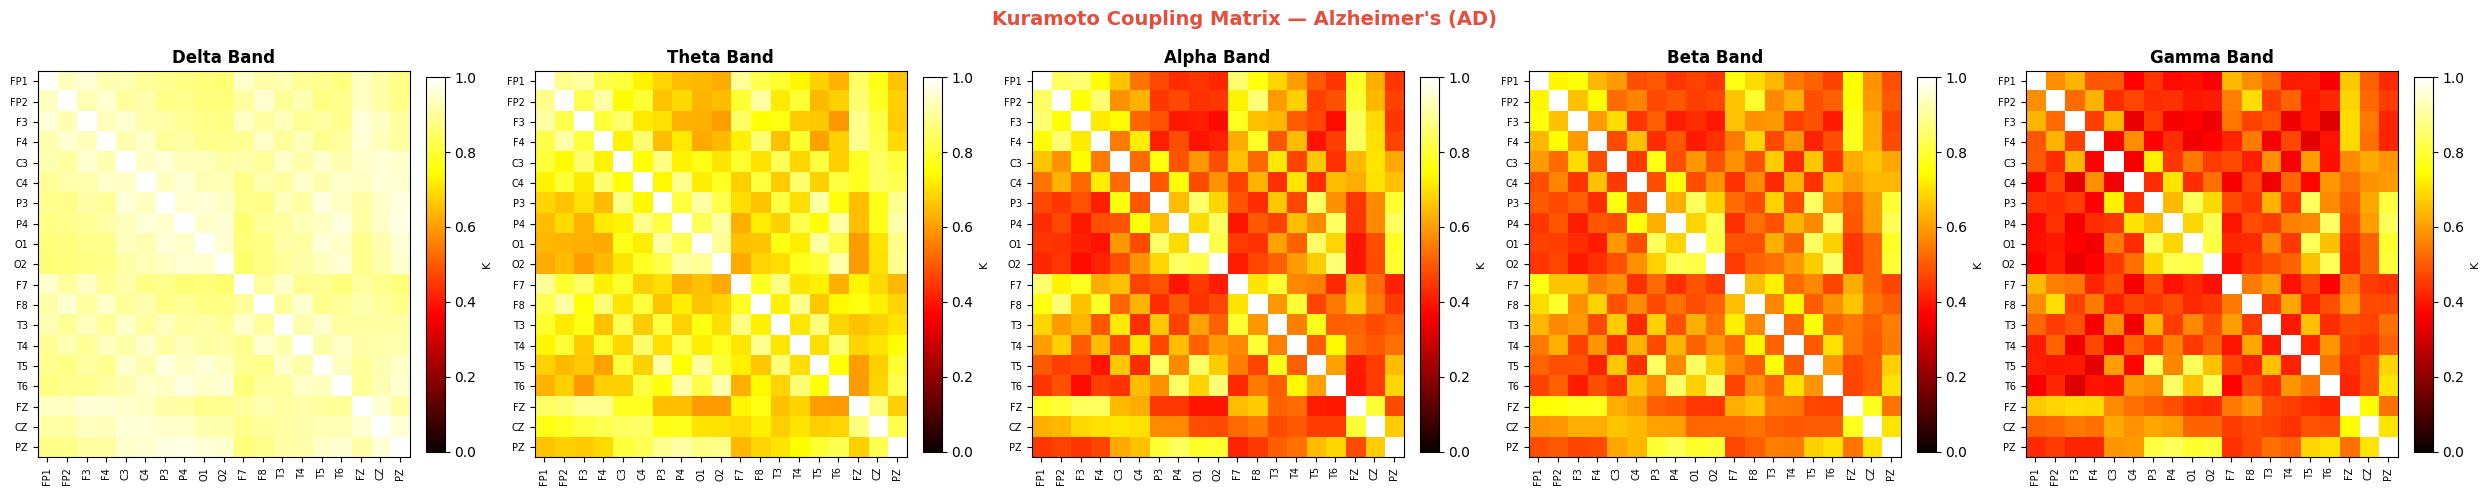

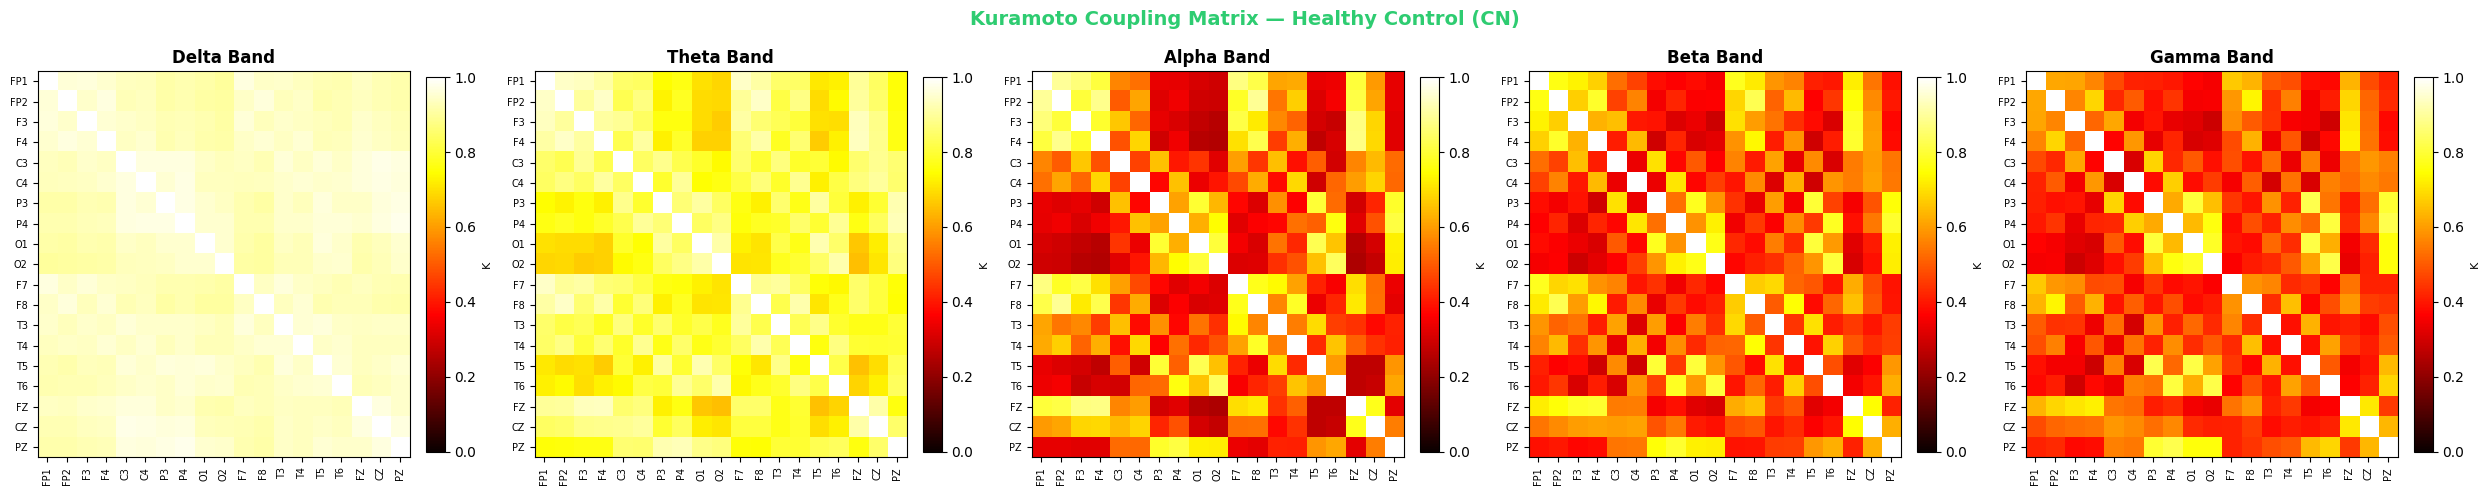

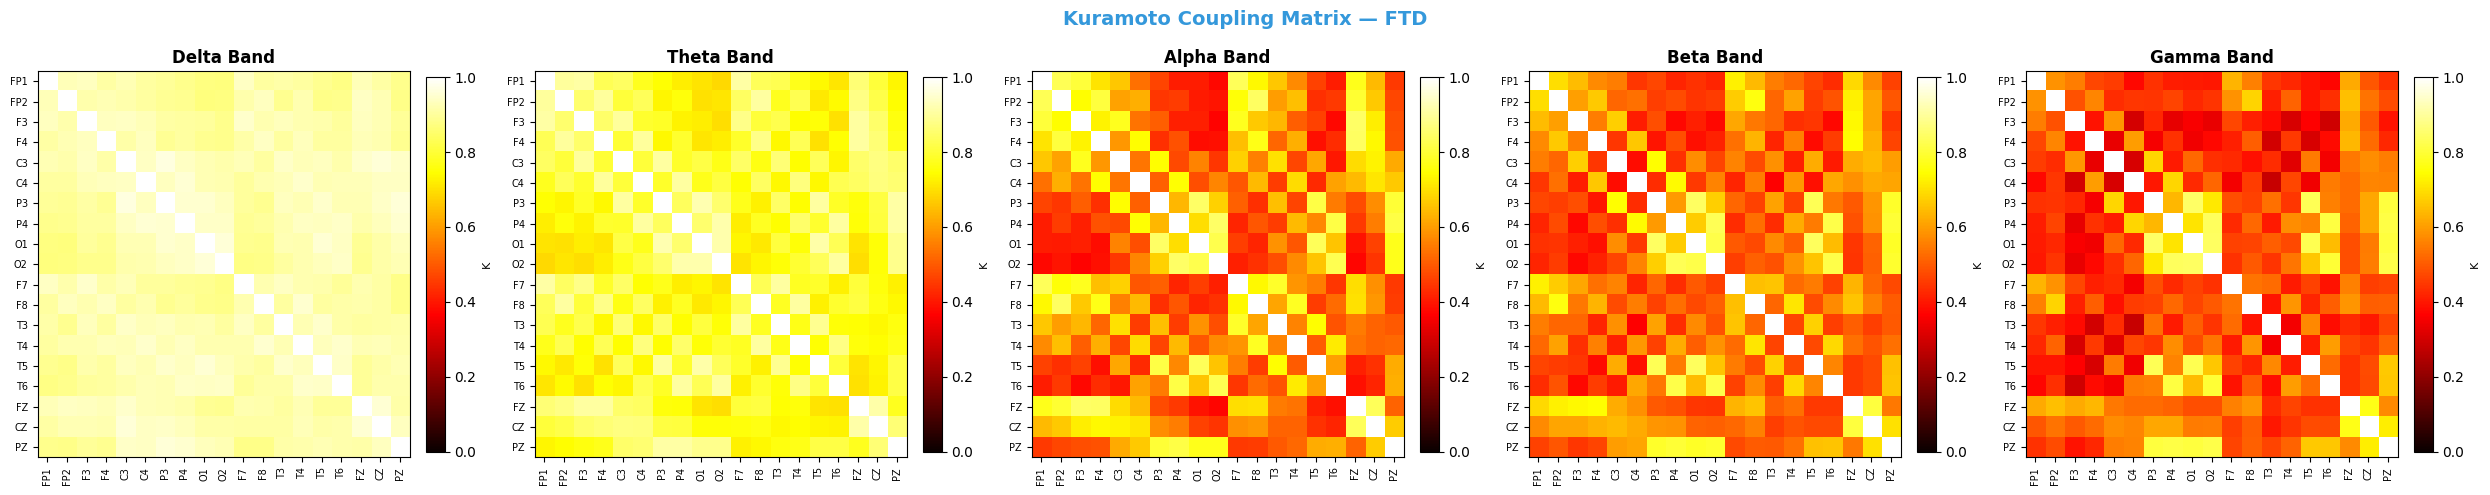

In [ ]:
GROUP_LABELS = {"A": "Alzheimer's (AD)", "C": "Healthy Control (CN)", "F": "FTD"}
GROUP_COLORS = {"A": "#E74C3C", "C": "#2ECC71", "F": "#3498DB"}
band_names   = list(BANDS.keys())  # 5 bands only

for group in ["A", "C", "F"]:
    fig, axes = plt.subplots(1, 5, figsize=(25, 5))  # 1 row, 5 columns
    fig.suptitle(f"Kuramoto Coupling Matrix — {GROUP_LABELS[group]}",
                 fontsize=14, fontweight="bold", color=GROUP_COLORS[group])

    for ax, band in zip(axes, band_names):
        K  = mean_coupling[group][band]
        im = ax.imshow(K, vmin=0, vmax=1, cmap="hot", aspect="auto")
        ax.set_title(f"{band} Band", fontweight="bold")
        ax.set_xticks(range(len(ch_names_global)))
        ax.set_yticks(range(len(ch_names_global)))
        ax.set_xticklabels(ch_names_global, rotation=90, fontsize=7)
        ax.set_yticklabels(ch_names_global, fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label("K", fontsize=8)

    plt.tight_layout()
    plt.savefig(f"coupling_{group}.png", dpi=150, bbox_inches="tight")
    plt.show()

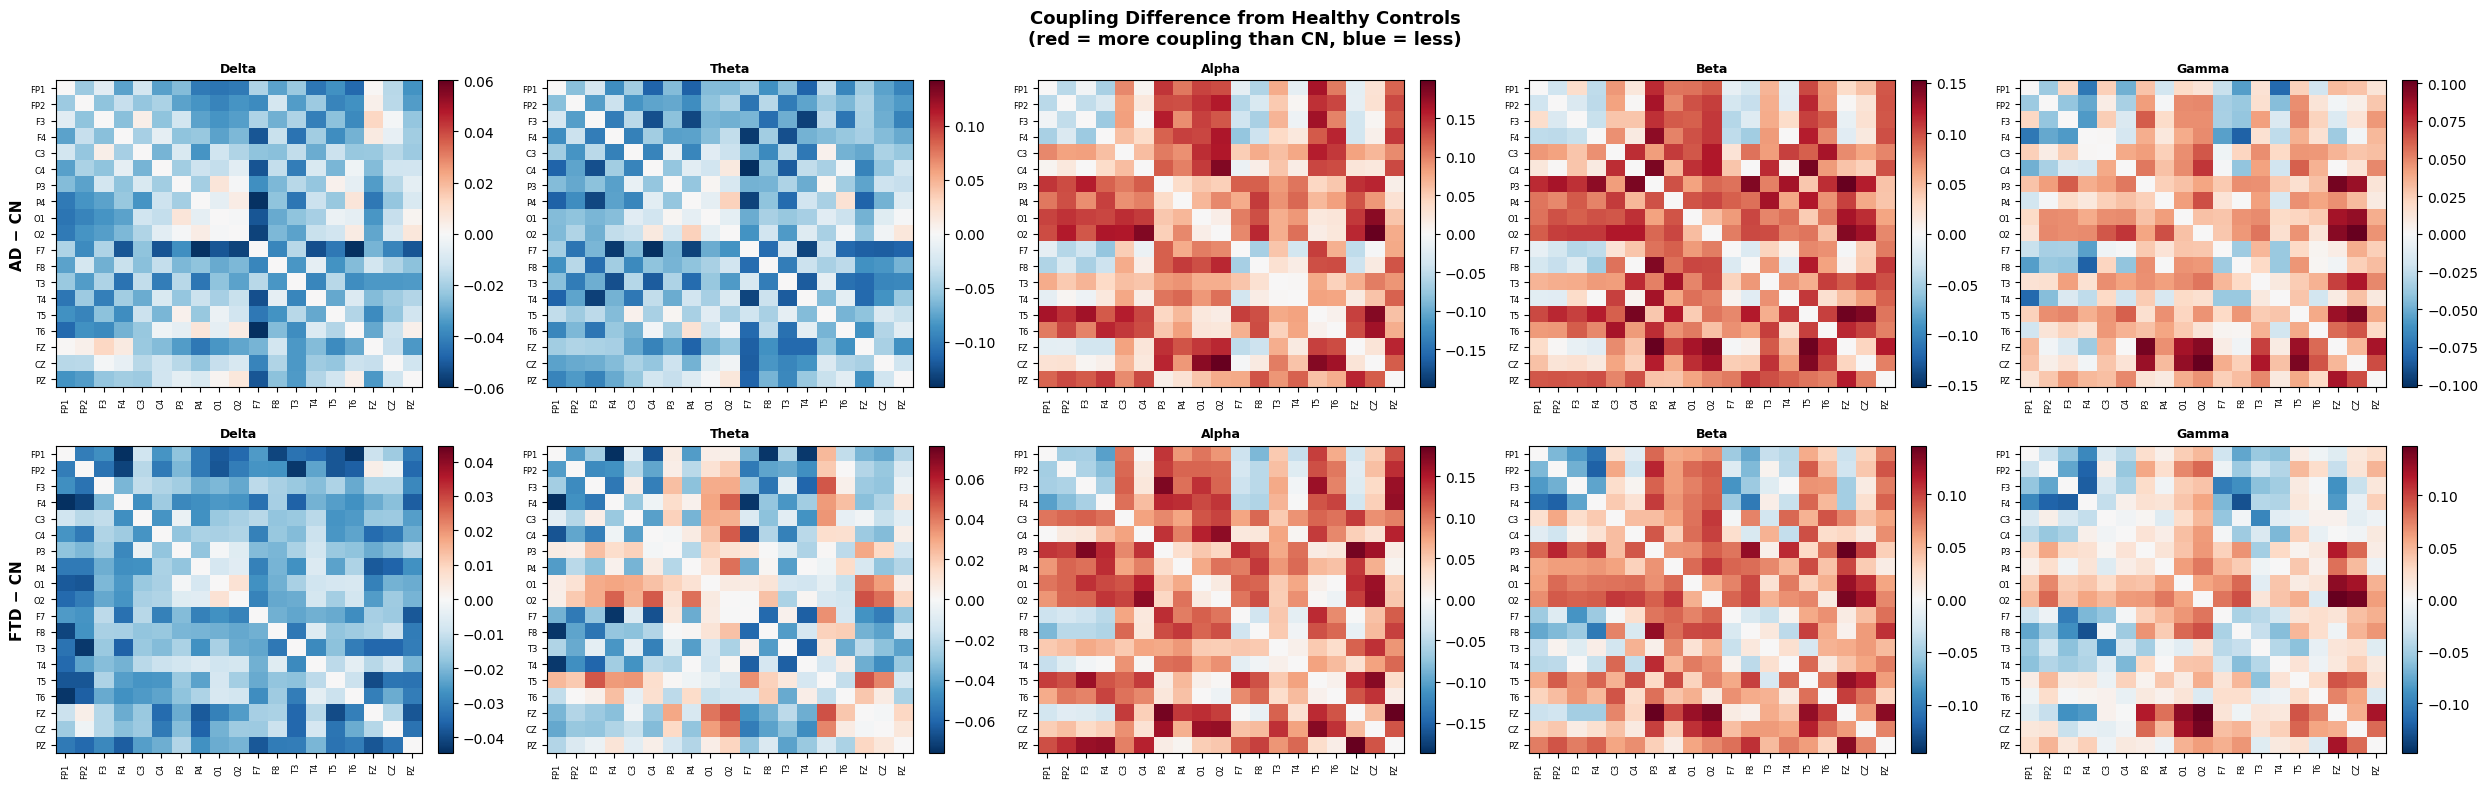

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(25, 8))  # 2 rows, 5 columns
fig.suptitle("Coupling Difference from Healthy Controls\n(red = more coupling than CN, blue = less)",
             fontsize=13, fontweight="bold")

comparisons = [("A", "C"), ("F", "C")]
row_labels  = ["AD − CN", "FTD − CN"]

for row, (g1, g2) in enumerate(comparisons):
    for col, band in enumerate(band_names):
        ax   = axes[row, col]
        diff = mean_coupling[g1][band] - mean_coupling[g2][band]
        lim  = np.abs(diff).max()
        im   = ax.imshow(diff, vmin=-lim, vmax=lim,
                         cmap="RdBu_r", aspect="auto")
        ax.set_title(f"{band}", fontweight="bold", fontsize=9)
        ax.set_xticks(range(len(ch_names_global)))
        ax.set_yticks(range(len(ch_names_global)))
        ax.set_xticklabels(ch_names_global, rotation=90, fontsize=6)
        ax.set_yticklabels(ch_names_global, fontsize=6)
        if col == 0:
            ax.set_ylabel(row_labels[row], fontsize=11, fontweight="bold")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig("coupling_difference.png", dpi=150, bbox_inches="tight")
plt.show()

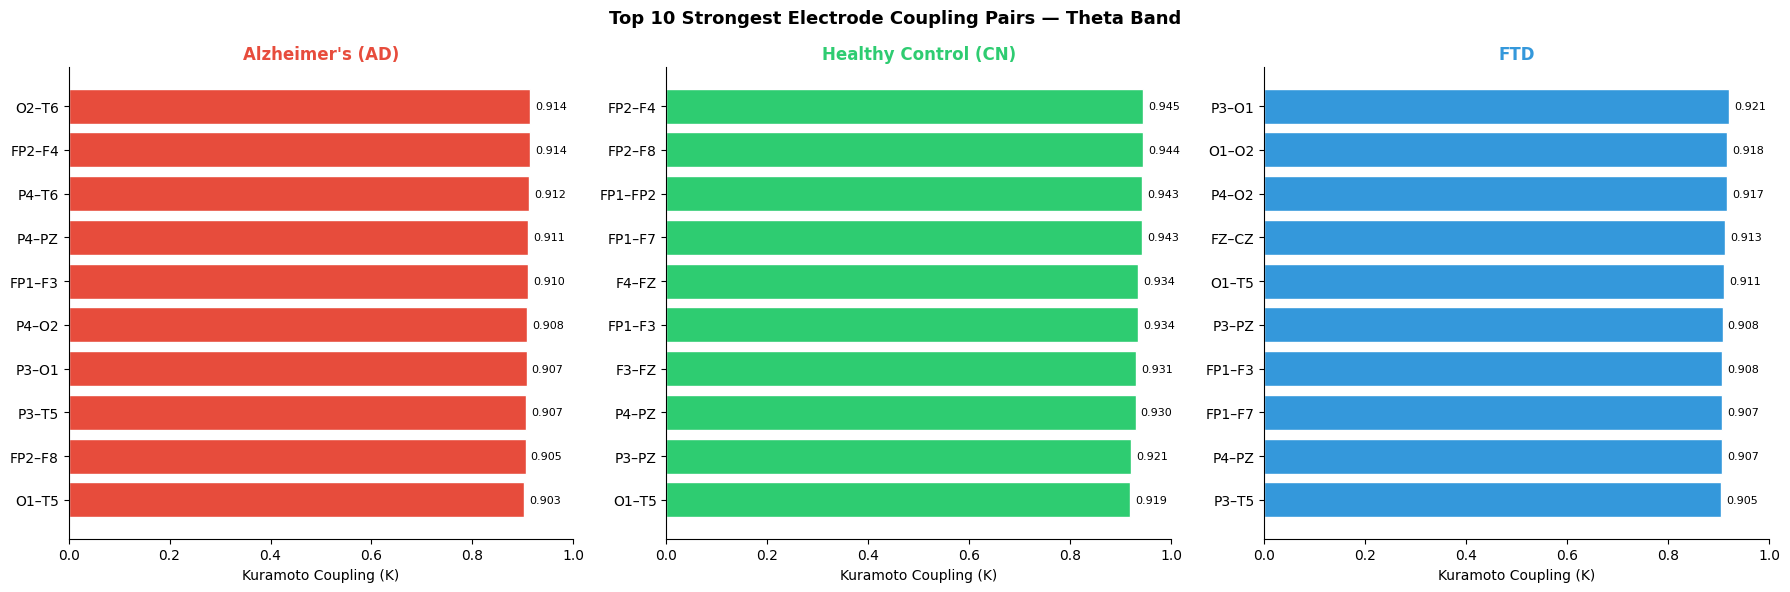

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Top 10 Strongest Electrode Coupling Pairs — Theta Band",
             fontsize=13, fontweight="bold")

for ax, group in zip(axes, ["A", "C", "F"]):
    K    = mean_coupling[group]["Theta"]
    n_ch = len(ch_names_global)
    pairs = []
    for i in range(n_ch):
        for j in range(i+1, n_ch):
            pairs.append((K[i, j], ch_names_global[i], ch_names_global[j]))
    pairs.sort(reverse=True)
    top10       = pairs[:10]
    pair_labels = [f"{p[1]}–{p[2]}" for p in top10]
    pair_vals   = [p[0] for p in top10]

    bars = ax.barh(pair_labels[::-1], pair_vals[::-1],
                   color=GROUP_COLORS[group], edgecolor="white")
    ax.set_title(GROUP_LABELS[group], fontweight="bold",
                 color=GROUP_COLORS[group])
    ax.set_xlabel("Kuramoto Coupling (K)")
    ax.set_xlim(0, 1)
    for bar, val in zip(bars, pair_vals[::-1]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.3f}", va='center', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("top_coupling_pairs.png", dpi=150, bbox_inches="tight")
plt.show()